<a href="https://colab.research.google.com/github/melsousa/LSTM-demand-forecast/blob/main/LSTMFrexco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from numpy.lib.npyio import DataSource
# Importando
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

df = pd.read_excel('Dados.xlsx', sheet_name='Query result')

In [14]:
demand = df['Vendas'].values

normalizando o dataset

In [15]:
# Normalização dos dados
scaler = MinMaxScaler(feature_range=(0, 1))
demand = scaler.fit_transform(demand.reshape(-1,1))


dividido em conjuntos de treinamento e teste



In [16]:
# Divisão em treinamento e teste
train_size = int(len(demand) * 0.8)
test_size = len(demand) - train_size
train, test = demand[0:train_size,:], demand[train_size:len(demand),:]

In [17]:
# Conversão dos dados para a forma (samples, time steps, features)
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

Definindo que o look_back, olhará 5 dias atrás 

In [18]:
look_back = 5
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

In [19]:
# Reshape dos dados para a forma (samples, time steps, features)
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [20]:
# Criação do modelo
model = Sequential()
model.add(LSTM(230, input_shape=(look_back, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [21]:
# Treinamento do modelo
model.fit(x=trainX, 
          y=trainY, 
          shuffle=True,
          validation_data=(testX, testY), 
          epochs=250, 
          batch_size=1, 
          verbose=2)

Epoch 1/250
30/30 - 2s - loss: 0.0960 - val_loss: 0.1944 - 2s/epoch - 79ms/step
Epoch 2/250
30/30 - 0s - loss: 0.0773 - val_loss: 0.2344 - 175ms/epoch - 6ms/step
Epoch 3/250
30/30 - 0s - loss: 0.0742 - val_loss: 0.2161 - 163ms/epoch - 5ms/step
Epoch 4/250
30/30 - 0s - loss: 0.0649 - val_loss: 0.1504 - 185ms/epoch - 6ms/step
Epoch 5/250
30/30 - 0s - loss: 0.0655 - val_loss: 0.2007 - 174ms/epoch - 6ms/step
Epoch 6/250
30/30 - 0s - loss: 0.0683 - val_loss: 0.1722 - 168ms/epoch - 6ms/step
Epoch 7/250
30/30 - 0s - loss: 0.0649 - val_loss: 0.2020 - 199ms/epoch - 7ms/step
Epoch 8/250
30/30 - 0s - loss: 0.0652 - val_loss: 0.1575 - 178ms/epoch - 6ms/step
Epoch 9/250
30/30 - 0s - loss: 0.0668 - val_loss: 0.1303 - 171ms/epoch - 6ms/step
Epoch 10/250
30/30 - 0s - loss: 0.0637 - val_loss: 0.1638 - 172ms/epoch - 6ms/step
Epoch 11/250
30/30 - 0s - loss: 0.0650 - val_loss: 0.2159 - 162ms/epoch - 5ms/step
Epoch 12/250
30/30 - 0s - loss: 0.0658 - val_loss: 0.1325 - 175ms/epoch - 6ms/step
Epoch 13/250
30

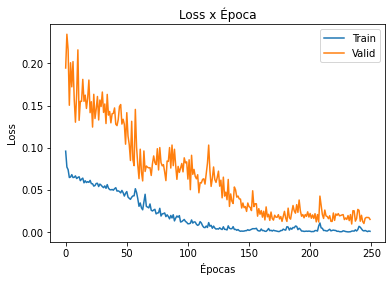

In [22]:
train_loss_per_epoch = model.history.history['loss']
plt.plot(range(len(train_loss_per_epoch)), train_loss_per_epoch, label='Train')
validation_loss_per_epoch = model.history.history['val_loss']
plt.plot(range(len(validation_loss_per_epoch)), validation_loss_per_epoch, label='Valid')
plt.title("Loss x Época")
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

Previsão de demanda para 1 dia

1/1 [==============================] - 0s 385ms/step


Text(0.5, 1.0, 'Gráfico de Demanda x dia')

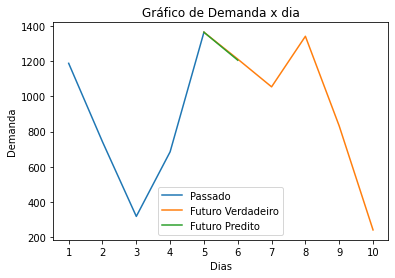

In [23]:
# Dia inicial da visualização
dia_inicial=2

# Primeiros 5 dias da série.
last_5 = demand[dia_inicial:dia_inicial+5]
last_5 = np.reshape(last_5, (1, 5, 1))

# Do 6º ao 10º dia
next_5 = demand[dia_inicial+5:dia_inicial+5+5]
next_5 = scaler.inverse_transform(next_5)

# Previsão do que seria do 6º ao 10º dia
next_5_pred = model.predict(last_5)
next_5_pred = scaler.inverse_transform(next_5_pred)

# Transformação inversão para os últimos 5 dias.
last_5 = demand[dia_inicial:dia_inicial+5]
last_5 = scaler.inverse_transform(last_5)

# Plota
plt.plot(range(1,len(last_5)+1), last_5, label='Passado')
plt.plot(range(len(last_5), len(last_5)+len(next_5)+1),np.concatenate((last_5[-1].reshape(-1,1),next_5)),label='Futuro Verdadeiro')
plt.plot(range(len(last_5), len(last_5)+len(next_5_pred)+1),np.concatenate((last_5[-1].reshape(-1,1),next_5_pred)),label='Futuro Predito')
plt.xticks(range(1,11))
plt.xlabel('Dias')
plt.ylabel('Demanda')
plt.legend()
plt.title('Gráfico de Demanda x dia')

Previsão de demanda para os proxímos 5 dias

1/1 [==============================] - 0s 29ms/step


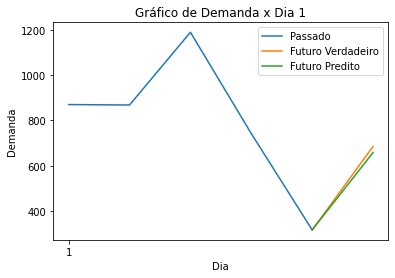

1/1 [==============================] - 0s 17ms/step


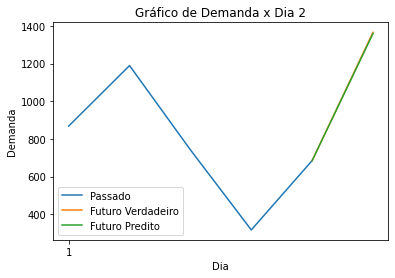

1/1 [==============================] - 0s 19ms/step


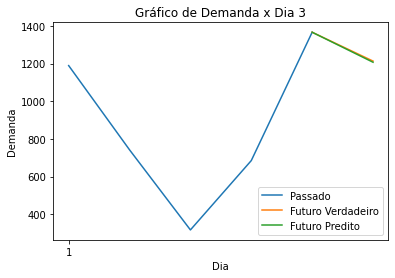

1/1 [==============================] - 0s 17ms/step


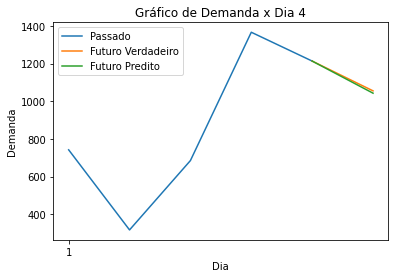

1/1 [==============================] - 0s 17ms/step


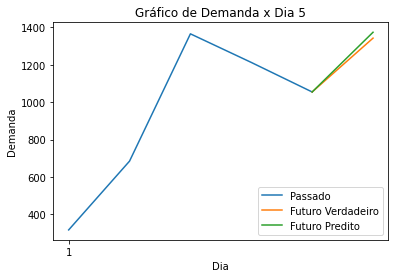

In [38]:
#  Previsão para os proxímos 5 dias

for i in range(5):
  # Dia inicial da visualização
  dia_inicial = i
  
  # Primeiros 5 dias da série.
  last_5 = demand[dia_inicial:dia_inicial+5]
  last_5 = np.reshape(last_5, (1, 5, 1))
  
  # Do 6º ao 10º dia
  next_5 = demand[dia_inicial+5:dia_inicial+5+1]
  next_5 = scaler.inverse_transform(next_5)
  
  # Previsão do que seria do 6º ao 10º dia
  next_5_pred = model.predict(last_5)
  next_5_pred = scaler.inverse_transform(next_5_pred)
  
  # Transformação inversão para os últimos 5 dias.
  last_5 = demand[dia_inicial:dia_inicial+5]
  last_5 = scaler.inverse_transform(last_5)
  
  # Plota
  plt.plot(range(1,len(last_5)+1), last_5, label='Passado')
  
  if next_5.shape[0] > 0:
      plt.plot(range(len(last_5), len(last_5)+len(next_5)+1),np.concatenate((last_5[-1].reshape(-1,1),next_5)),label='Futuro Verdadeiro')
  
  if next_5_pred.shape[0] > 0:
      plt.plot(range(len(last_5), len(last_5)+len(next_5_pred)+1),np.concatenate((last_5[-1].reshape(-1,1),next_5_pred)),label='Futuro Predito')
  
  
  plt.xticks(range(1,2))
  plt.xlabel('Dia')
  plt.ylabel('Demanda')
  plt.legend()
  plt.title('Gráfico de Demanda x Dia ' + str(i+1))
  plt.show()
